<a href="https://colab.research.google.com/github/LuisMesa10/teledeteccionPorRadar/blob/main/Parcial_visi%C3%B3n_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2  # Procesamiento de imágenes
import numpy as np  # Cálculos numéricos
import matplotlib.pyplot as plt  # Visualización
import os  # Manejo de rutas

In [2]:
from google.colab import drive  # Importa la librería de Google Drive
drive.mount('/content/drive')  # Monta tu Drive para acceder a archivos

Mounted at /content/drive


In [6]:
basepath = '/content/drive/MyDrive/parcial vision IA'  # Cambia esto si tu ruta es diferente

imagenes = [
    'img1_vv.tiff',
    'img2_vv.tiff',
    'img3_vv.tiff',
    'img4_vv.tiff',
    'img5_vv.tiff'
]

In [7]:
def rescalar_imagen(img):  # Función para adaptar la imagen SAR
    img2 = img.astype(np.float32)  # Convertir a float para cálculos

    escala_display = np.mean(img2) * 3.0  # Umbral basado en la media

    min_val = np.min(img2)  # Valor mínimo

    img2[img2 > escala_display] = escala_display
    # Limita valores muy altos (reduce outliers)

    img2[img2 < min_val] = 0
    # Asegura que no haya valores negativos

    img3 = 255.0 * (img2 / escala_display)
    # Escala valores a rango 0–255

    return img3.astype(np.uint8)
    # Convierte a formato imagen visible


Procesando imagen: img1_vv.tiff
Dimensiones: (9726, 12821)
Tipo de dato: uint8
Valor máximo: 28
Valor promedio: 0.39972355880828164
Valor mínimo: 0


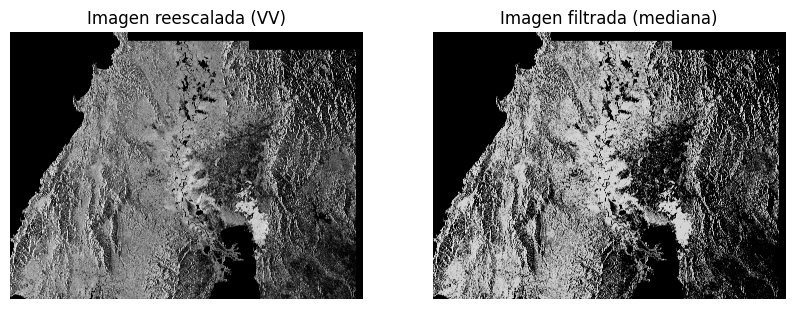

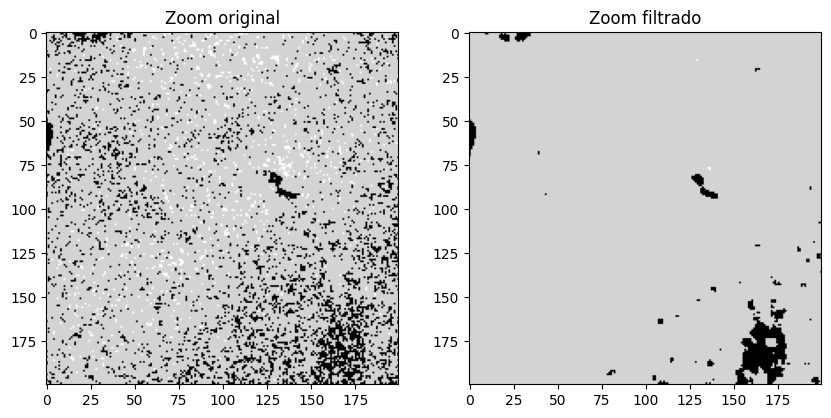

Imágenes guardadas correctamente.

Procesando imagen: img2_vv.tiff
Dimensiones: (9725, 12821)
Tipo de dato: uint8
Valor máximo: 37
Valor promedio: 0.3645981197701634
Valor mínimo: 0


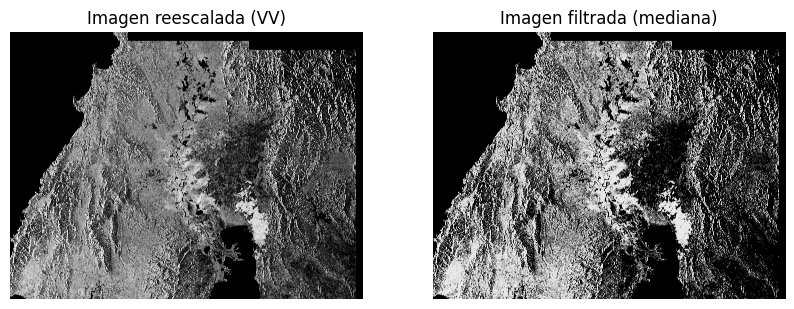

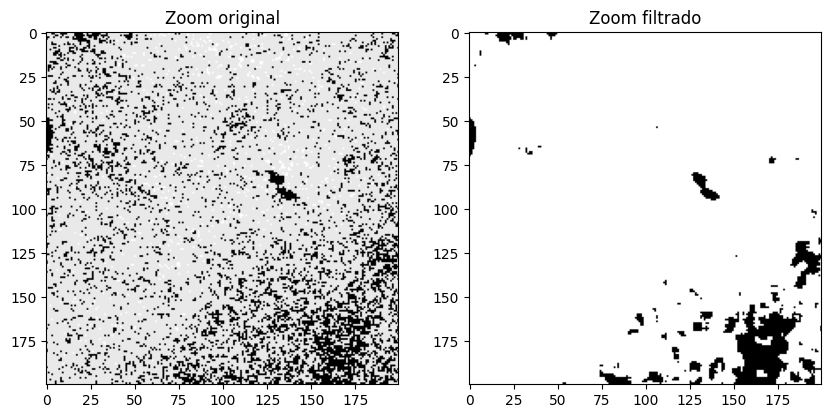

Imágenes guardadas correctamente.

Procesando imagen: img3_vv.tiff
Dimensiones: (9724, 12820)
Tipo de dato: uint8
Valor máximo: 73
Valor promedio: 0.3631212815357534
Valor mínimo: 0
Imágenes guardadas correctamente.

Procesando imagen: img4_vv.tiff
Dimensiones: (9737, 12629)
Tipo de dato: uint8
Valor máximo: 29
Valor promedio: 0.35571509803565826
Valor mínimo: 0
Imágenes guardadas correctamente.

Procesando imagen: img5_vv.tiff
Dimensiones: (9728, 12820)
Tipo de dato: uint8
Valor máximo: 28
Valor promedio: 0.3477355761582437
Valor mínimo: 0
Imágenes guardadas correctamente.


In [8]:
for i, imgpath in enumerate(imagenes):
    # Recorre todas las imágenes una por una

    print(f'\nProcesando imagen: {imgpath}')

    ruta = os.path.join(basepath, imgpath)
    # Construye la ruta completa

    # 🔥 CAMBIO CLAVE PARA EVITAR ERRORES DE MEMORIA
    img = cv2.imread(ruta, cv2.IMREAD_REDUCED_GRAYSCALE_2)
    # Carga la imagen en menor resolución (más liviana)

    if img is None:
        print('Error al cargar la imagen.')
        continue

    print('Dimensiones:', img.shape)
    print('Tipo de dato:', img.dtype)
    print('Valor máximo:', np.max(img))
    print('Valor promedio:', np.mean(img))
    print('Valor mínimo:', np.min(img))

    # =========================
    # REESCALADO
    # =========================
    img_rescaled = rescalar_imagen(img)

    # =========================
    # FILTRADO SPECKLE
    # =========================
    img_filtrada = cv2.medianBlur(img_rescaled, 5)

    # Define h and w for the current image, available for conditional zoom
    h, w = img_filtrada.shape

    # =========================
    # VISUALIZACIÓN (solo 2 imágenes)
    # =========================
    if i < 2:
        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.title('Imagen reescalada (VV)')
        plt.imshow(img_rescaled, cmap='gray')
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.title('Imagen filtrada (mediana)')
        plt.imshow(img_filtrada, cmap='gray')
        plt.axis('off')

        plt.show()

       # 🔍 ZOOM AUTOMÁTICO (no falla por tamaño)

        # ZOOM comparativo
        zoom_original = img_rescaled[h//2-100:h//2+100, w//2-100:w//2+100]
        zoom_filtrado = img_filtrada[h//2-100:h//2+100, w//2-100:w//2+100]

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.title('Zoom original')
        plt.imshow(zoom_original, cmap='gray')

        plt.subplot(1,2,2)
        plt.title('Zoom filtrado')
        plt.imshow(zoom_filtrado, cmap='gray')

        plt.show()

    # =========================
    # GUARDAR RESULTADOS
    # =========================
    nombre_base = imgpath.replace('.tiff', '')

    salida_rescaled = os.path.join(basepath, nombre_base + '_vv_reescalada.tiff')
    salida_filtrada = os.path.join(basepath, nombre_base + '_vv_filtrada.tiff')

    cv2.imwrite(salida_rescaled, img_rescaled)
    cv2.imwrite(salida_filtrada, img_filtrada)

    print('Imágenes guardadas correctamente.')

    # =========================
    # LIBERAR MEMORIA
    # =========================
    del img, img_rescaled, img_filtrada

RETO 2

In [9]:
from sklearn.cluster import KMeans  # Algoritmo de clustering

In [12]:
img_original_path = os.path.join(basepath, imagenes[0]) #se carga la primera imagen para el analisis
img_original = cv2.imread(img_original_path, cv2.IMREAD_REDUCED_GRAYSCALE_2)

img_original = rescalar_imagen(img_original)

img_filtrada = cv2.medianBlur(img_original, 5)
img_filtrada = rescalar_imagen(img_filtrada)  # 🔥 ESTE ES EL FIX

In [13]:
img_original = rescalar_imagen(img_original)  # Igual que en Reto 1

In [14]:
def aplicar_kmeans(img, k=3):

    data = img.reshape((-1,1)).astype(np.float32)

    # 🔥 tomar SOLO 5% de los datos
    cantidad = int(data.shape[0] * 0.05)

    indices = np.random.choice(data.shape[0], cantidad, replace=False)
    muestra = data[indices]

    kmeans = KMeans(n_clusters=k, random_state=0)

    kmeans.fit(muestra)  # entrena con pocos datos

    labels = kmeans.predict(data)  # aplica a toda la imagen

    clustered = labels.reshape(img.shape)
    clustered = (clustered / (k-1)) * 255

    return clustered.astype(np.uint8)

In [15]:
img_original = rescalar_imagen(img_original)

cluster_original = aplicar_kmeans(img_original, k=4)
cluster_filtrada = aplicar_kmeans(img_filtrada, k=4)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


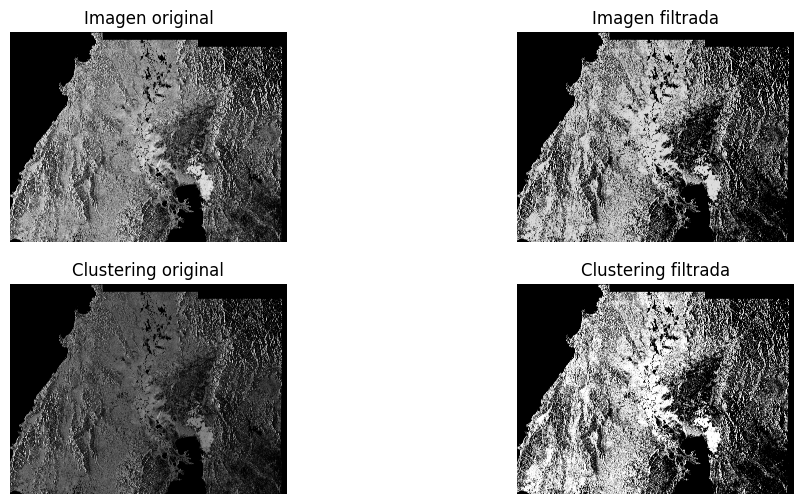

In [16]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.title('Imagen original')
plt.imshow(img_original, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title('Imagen filtrada')
plt.imshow(img_filtrada, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title('Clustering original')
plt.imshow(cluster_original, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title('Clustering filtrada')
plt.imshow(cluster_filtrada, cmap='gray')
plt.axis('off')

plt.show()

RETO 3

In [17]:
def detectar_agua(img, cluster):
    clases = np.unique(cluster)
    promedios = [np.mean(img[cluster == c]) for c in clases]
    clase_agua = clases[np.argmin(promedios)]
    return clase_agua

agua_clase_original = detectar_agua(img_original, cluster_original)
agua_clase_filtrada = detectar_agua(img_filtrada, cluster_filtrada)

In [18]:
# Crear máscara binaria (agua = blanco, resto = negro)
mask_original = (cluster_original == agua_clase_original).astype(np.uint8) * 255
mask_filtrada = (cluster_filtrada == agua_clase_filtrada).astype(np.uint8) * 255

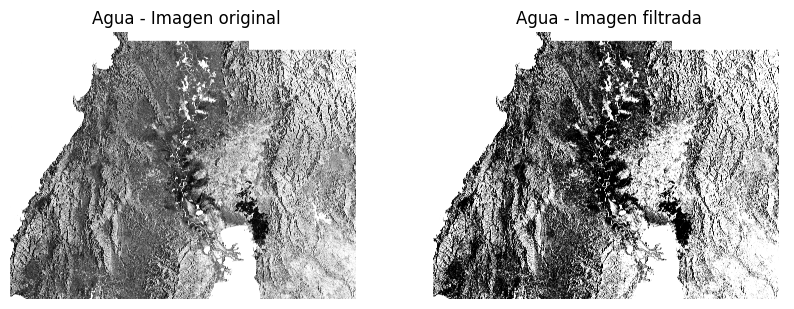

In [19]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title('Agua - Imagen original')
plt.imshow(mask_original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Agua - Imagen filtrada')
plt.imshow(mask_filtrada, cmap='gray')
plt.axis('off')

plt.show()

In [20]:
def porcentaje_agua(mask):
    total_pixeles = mask.size  # Número total de píxeles
    pixeles_agua = np.sum(mask == 255)  # Conteo de píxeles blancos (agua)

    porcentaje = (pixeles_agua / total_pixeles) * 100
    return porcentaje

print("Porcentaje de agua (imagen original):", porcentaje_agua(mask_original), "%")
print("Porcentaje de agua (imagen filtrada):", porcentaje_agua(mask_filtrada), "%")

Porcentaje de agua (imagen original): 62.743134267992204 %
Porcentaje de agua (imagen filtrada): 61.571525118566164 %
